# Predicting NBA field goal making - Modeling
## Capstone Project One : Springboard Data Science career track
## Notebook by Luis Vallesteros

### 1. Problem to Solve

Simply put, the 2023 NBA season provides a unique dataset where so many ends can be sliced down to deconstruct the optimal shot via advanced analytics. I want to take my own shot at this through a predictive model classifying field goals by position, area, and distance to provide NBA players the best shot possible.

### 2. Questions to Address

Optimal Shot Selection:

What are the most efficient shooting zones for each player based on their historical performance and how can this be used to recommend optimal shot selection?
Predictive Modeling:

Can we build a predictive model to determine the likelihood of a shot being successful based on factors such as player position, shot distance, and shot type?

What is the impact of the remaining game time on shot selection and success?

How do players' shot choices and success rates change as the clock winds down in each quarter?

### 3. Import Necessary Packages and Pre-Process the Data

In [26]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime


In [5]:
#Loading previously cleansed data data:
shot_data = pd.read_csv('NBA_2023_Shots.csv')

#Head?
shot_data.head()
shot_data.columns

Index(['SEASON_1', 'SEASON_2', 'TEAM_ID', 'TEAM_NAME', 'PLAYER_ID',
       'PLAYER_NAME', 'POSITION_GROUP', 'POSITION', 'GAME_DATE', 'GAME_ID',
       'HOME_TEAM', 'AWAY_TEAM', 'EVENT_TYPE', 'SHOT_MADE', 'ACTION_TYPE',
       'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT'],
      dtype='object')

In [6]:
#This will be defined as my response variable (categorical)

shot_data['SHOT_RESULT'] = shot_data['EVENT_TYPE'].map({'Made Shot': 1, 'Missed Shot': 0})

In [7]:
# Check for missing values
print(shot_data.isnull().sum())

# Basic statistics
print(shot_data.describe())


SEASON_1             0
SEASON_2             0
TEAM_ID              0
TEAM_NAME            0
PLAYER_ID            0
PLAYER_NAME          0
POSITION_GROUP    1431
POSITION          1431
GAME_DATE            0
GAME_ID              0
HOME_TEAM            0
AWAY_TEAM            0
EVENT_TYPE           0
SHOT_MADE            0
ACTION_TYPE          0
SHOT_TYPE            0
BASIC_ZONE           0
ZONE_NAME            0
ZONE_ABB             0
ZONE_RANGE           0
LOC_X                0
LOC_Y                0
SHOT_DISTANCE        0
QUARTER              0
MINS_LEFT            0
SECS_LEFT            0
SHOT_RESULT          0
dtype: int64
       SEASON_1       TEAM_ID     PLAYER_ID       GAME_ID          LOC_X  \
count  217220.0  2.172200e+05  2.172200e+05  2.172200e+05  217220.000000   
mean     2023.0  1.610613e+09  1.232999e+06  2.220062e+07       0.187650   
std         0.0  8.679494e+00  6.407190e+05  3.557616e+02      11.321753   
min      2023.0  1.610613e+09  2.544000e+03  2.220000e+07     

In [8]:
# Encode categorical features
shot_data = pd.get_dummies(shot_data, columns=['POSITION_GROUP', 'BASIC_ZONE', 'ACTION_TYPE'])

# Feature engineering: Convert MINS_LEFT and SECS_LEFT to total seconds left
shot_data['SECONDS_LEFT'] = shot_data['MINS_LEFT'] * 60 + shot_data['SECS_LEFT']


In [9]:
# Select features and target
features = ['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'SECONDS_LEFT'] + list(shot_data.columns[shot_data.columns.str.startswith('POSITION_')]) + list(shot_data.columns[shot_data.columns.str.startswith('BASIC_ZONE_')])
X = shot_data[features]
y = shot_data['SHOT_RESULT']


In [10]:
#Data looks good. Let's now sample what we have. (We are not using any time series data for this project.)

X.head()

,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,SECONDS_LEFT,POSITION_GROUP_C,POSITION_GROUP_F,POSITION_GROUP_G,BASIC_ZONE_Above the Break 3,BASIC_ZONE_Backcourt,BASIC_ZONE_In The Paint (Non-RA),BASIC_ZONE_Left Corner 3,BASIC_ZONE_Mid-Range,BASIC_ZONE_Restricted Area,BASIC_ZONE_Right Corner 3
0,23.4,12.95,24,1,680,False,False,True,False,False,False,True,False,False,False
1,-0.4,31.45,26,1,652,True,False,False,True,False,False,False,False,False,False
2,-1.3,5.25,1,1,639,False,False,True,False,False,False,False,False,True,False
3,-0.1,7.25,2,1,631,True,False,False,False,False,False,False,False,True,False
4,1.8,7.15,2,1,605,False,True,False,False,False,False,False,False,True,False


In [11]:
X.columns

Index(['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'SECONDS_LEFT',
       'POSITION_GROUP_C', 'POSITION_GROUP_F', 'POSITION_GROUP_G',
       'BASIC_ZONE_Above the Break 3', 'BASIC_ZONE_Backcourt',
       'BASIC_ZONE_In The Paint (Non-RA)', 'BASIC_ZONE_Left Corner 3',
       'BASIC_ZONE_Mid-Range', 'BASIC_ZONE_Restricted Area',
       'BASIC_ZONE_Right Corner 3'],
      dtype='object')

In [12]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: SHOT_RESULT, dtype: int64

In [13]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling Time!

### 1. Logistic Regression

In [14]:
# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred)}")

[[18291  4579]
 [11769  8805]]
              precision    recall  f1-score   support

           0       0.61      0.80      0.69     22870
           1       0.66      0.43      0.52     20574

    accuracy                           0.62     43444
   macro avg       0.63      0.61      0.60     43444
weighted avg       0.63      0.62      0.61     43444

ROC-AUC Score: 0.6138743551969282


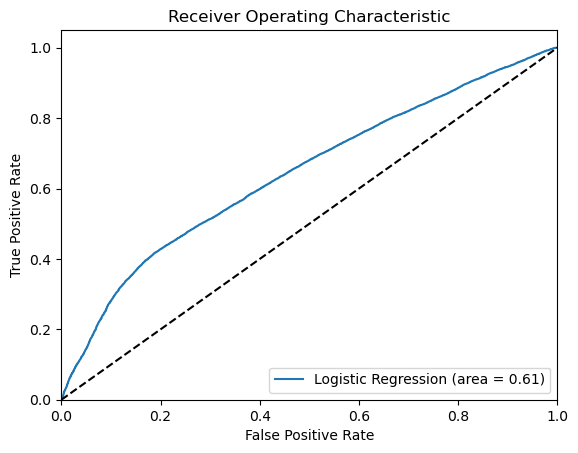

In [15]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### 2. KNN

In [16]:
# KNN Classifier
knn = KNeighborsClassifier()
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='roc_auc')
knn_grid.fit(X_train_scaled, y_train)

# Best KNN Model
best_knn = knn_grid.best_estimator_
y_knn_pred = best_knn.predict(X_test_scaled)
print("KNN Classification Report:\n", classification_report(y_test, y_knn_pred))
print("KNN ROC-AUC Score:", roc_auc_score(y_test, y_knn_pred))

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.65      0.63     22870
           1       0.57      0.51      0.54     20574

    accuracy                           0.59     43444
   macro avg       0.59      0.58      0.58     43444
weighted avg       0.59      0.59      0.59     43444

KNN ROC-AUC Score: 0.5837833751566168


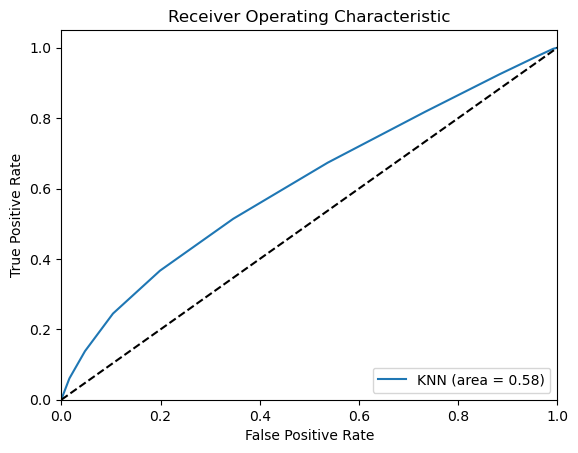

In [17]:
# Plot ROC curve for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, best_knn.predict_proba(X_test_scaled)[:, 1])
plt.figure()
plt.plot(fpr_knn, tpr_knn, label='KNN (area = %0.2f)' % roc_auc_score(y_test, y_knn_pred))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### 3. Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, 30], 'min_samples_split': [2, 5, 10]}
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc')
rf_grid.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [19]:
# Best Random Forest Model
best_rf = rf_grid.best_estimator_
y_rf_pred = best_rf.predict(X_test_scaled)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))
print("Random Forest ROC-AUC Score:", roc_auc_score(y_test, y_rf_pred))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.83      0.70     22870
           1       0.68      0.40      0.50     20574

    accuracy                           0.63     43444
   macro avg       0.64      0.62      0.60     43444
weighted avg       0.64      0.63      0.61     43444

Random Forest ROC-AUC Score: 0.6151682756484862


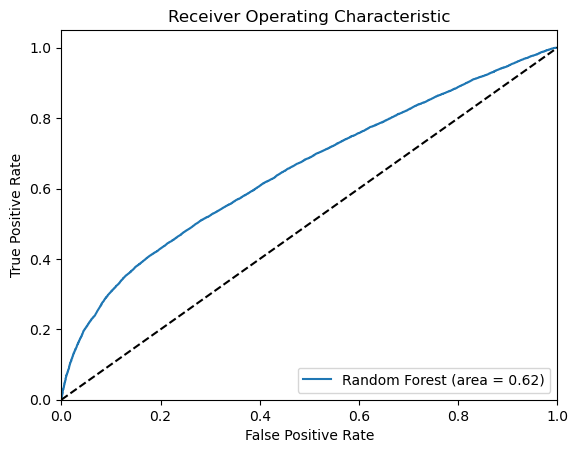

In [20]:
# Plot ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test_scaled)[:, 1])
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='Random Forest (area = %0.2f)' % roc_auc_score(y_test, y_rf_pred))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### 4. Comparing the Models

In [27]:
# Collect metrics
metrics = {
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_knn_pred), accuracy_score(y_test, y_rf_pred)],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, y_knn_pred), precision_score(y_test, y_rf_pred)],
    'Recall': [recall_score(y_test, y_pred), recall_score(y_test, y_knn_pred), recall_score(y_test, y_rf_pred)],
    'F1 Score': [f1_score(y_test, y_pred), f1_score(y_test, y_knn_pred), f1_score(y_test, y_rf_pred)],
    'ROC-AUC Score': [roc_auc_score(y_test, y_pred), roc_auc_score(y_test, y_knn_pred), roc_auc_score(y_test, y_rf_pred)]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1 Score  ROC-AUC Score
0  Logistic Regression  0.623699   0.657875  0.427967  0.518582       0.613874
1                  KNN  0.587469   0.571676  0.514047  0.541332       0.583783
2        Random Forest  0.626439   0.678176  0.401915  0.504715       0.615168


# 3. HyperParameter Tuning for GridSearchCV

## 1. Logistic Regression

In [28]:
lr = LogisticRegression()
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # 'liblinear' supports both L1 and L2 penalties
}

lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='roc_auc')
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
y_lr_pred = best_lr.predict(X_test_scaled)
print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_lr_pred))
print("Logistic Regression ROC-AUC Score:", roc_auc_score(y_test, y_lr_pred))

Best Logistic Regression Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.80      0.69     22870
           1       0.66      0.43      0.52     20574

    accuracy                           0.62     43444
   macro avg       0.63      0.61      0.60     43444
weighted avg       0.63      0.62      0.61     43444

Logistic Regression ROC-AUC Score: 0.6138252719746086


## 2. KNN

In [29]:
knn = KNeighborsClassifier()
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 for Manhattan distance, 2 for Euclidean distance
}

knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='roc_auc')
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
y_knn_pred = best_knn.predict(X_test_scaled)
print("Best KNN Parameters:", knn_grid.best_params_)
print("KNN Classification Report:\n", classification_report(y_test, y_knn_pred))
print("KNN ROC-AUC Score:", roc_auc_score(y_test, y_knn_pred))

Best KNN Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.65      0.63     22870
           1       0.57      0.51      0.54     20574

    accuracy                           0.59     43444
   macro avg       0.59      0.58      0.58     43444
weighted avg       0.59      0.59      0.59     43444

KNN ROC-AUC Score: 0.5837833751566168


## 3. Random Forest

In [32]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc')
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
y_rf_pred = best_rf.predict(X_test_scaled)
print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))
print("Random Forest ROC-AUC Score:", roc_auc_score(y_test, y_rf_pred))

Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.83      0.70     22870
           1       0.68      0.40      0.50     20574

    accuracy                           0.63     43444
   macro avg       0.64      0.62      0.60     43444
weighted avg       0.64      0.63      0.61     43444

Random Forest ROC-AUC Score: 0.6151682756484862


## 4. Final Comparison

In [33]:
metrics = {
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_lr_pred), accuracy_score(y_test, y_knn_pred), accuracy_score(y_test, y_rf_pred)],
    'Precision': [precision_score(y_test, y_lr_pred), precision_score(y_test, y_knn_pred), precision_score(y_test, y_rf_pred)],
    'Recall': [recall_score(y_test, y_lr_pred), recall_score(y_test, y_knn_pred), recall_score(y_test, y_rf_pred)],
    'F1 Score': [f1_score(y_test, y_lr_pred), f1_score(y_test, y_knn_pred), f1_score(y_test, y_rf_pred)],
    'ROC-AUC Score': [roc_auc_score(y_test, y_lr_pred), roc_auc_score(y_test, y_knn_pred), roc_auc_score(y_test, y_rf_pred)]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1 Score  ROC-AUC Score
0  Logistic Regression  0.623769   0.659141  0.425683  0.517291       0.613825
1                  KNN  0.587469   0.571676  0.514047  0.541332       0.583783
2        Random Forest  0.626439   0.678176  0.401915  0.504715       0.615168


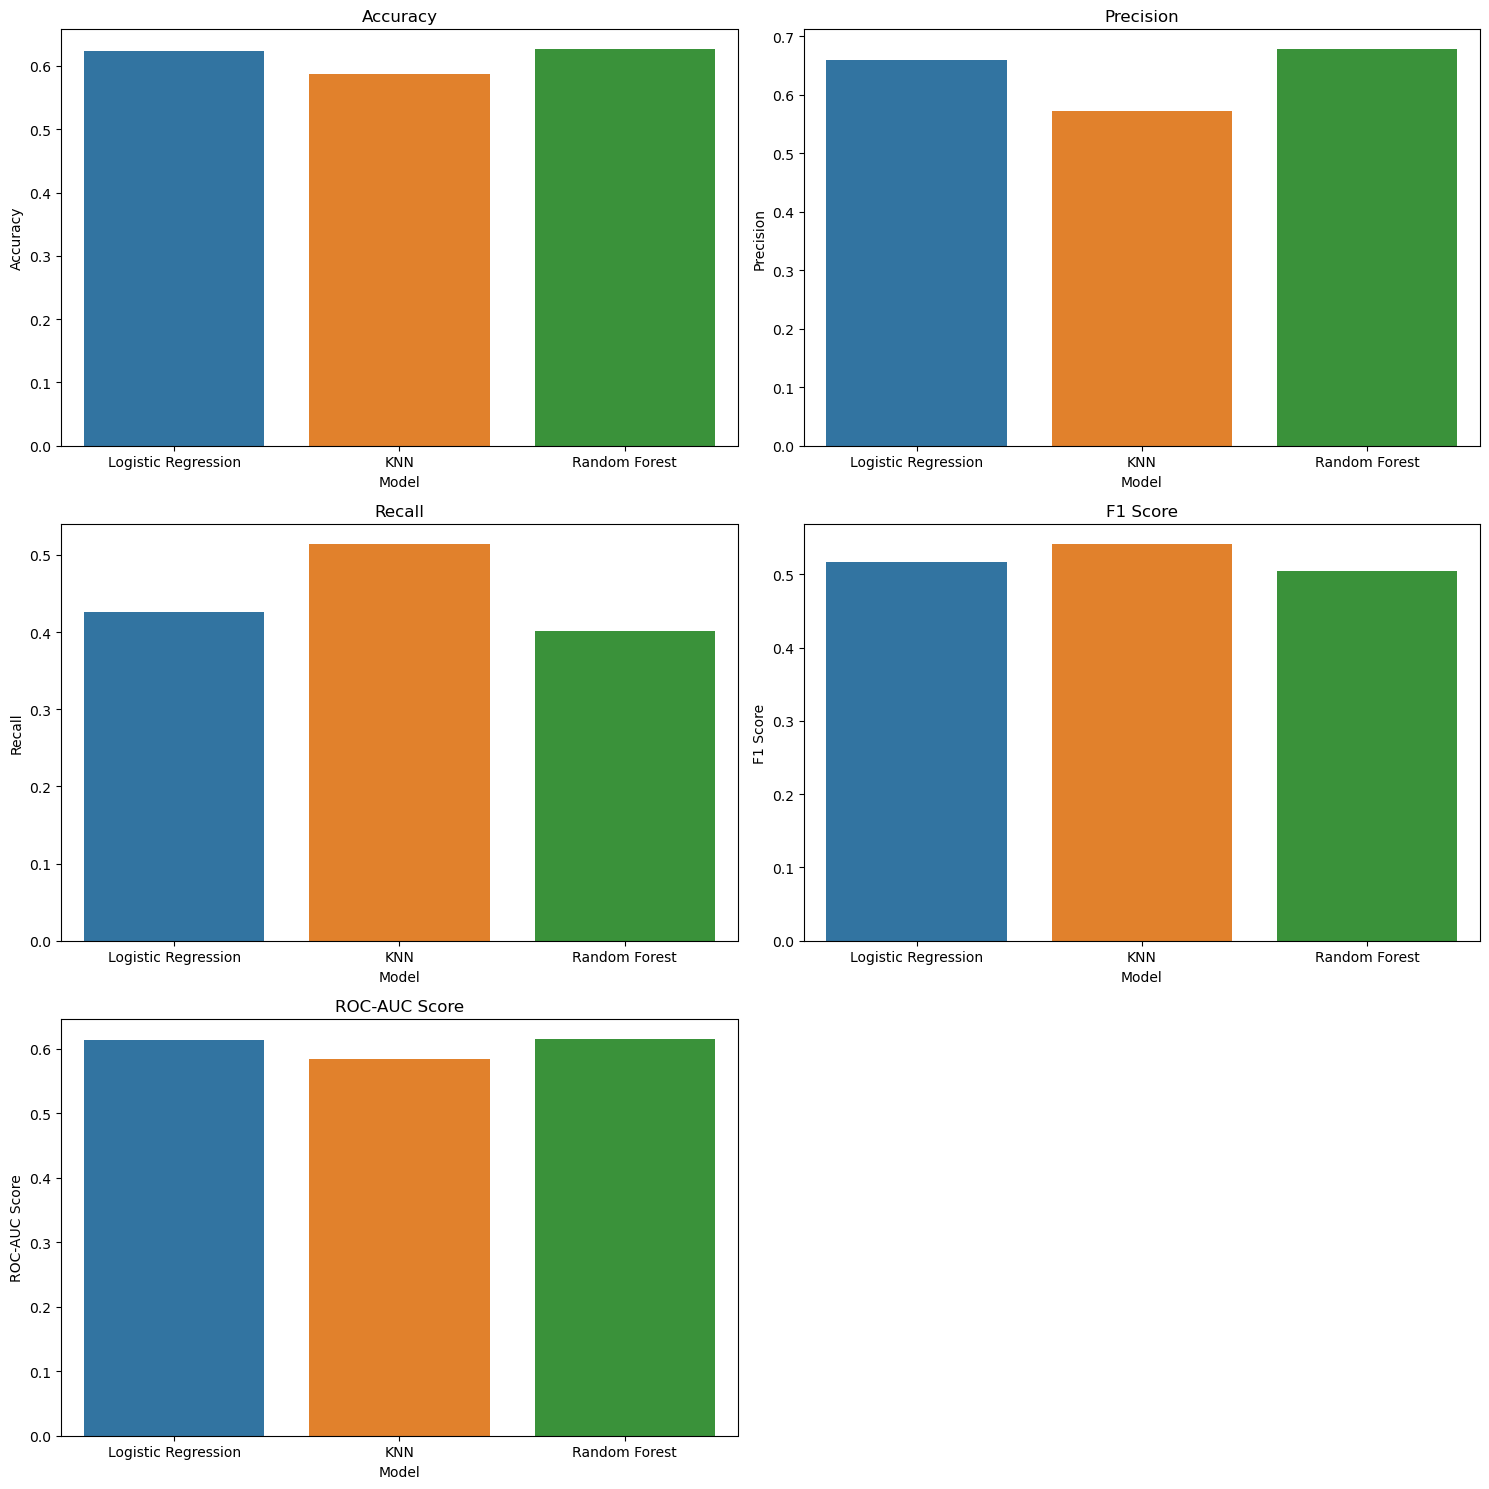

In [34]:
metrics_df = pd.DataFrame(metrics)

# Set up the matplotlib figure
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Plot Accuracy
sns.barplot(x='Model', y='Accuracy', data=metrics_df, ax=axes[0, 0])
axes[0, 0].set_title('Accuracy')

# Plot Precision
sns.barplot(x='Model', y='Precision', data=metrics_df, ax=axes[0, 1])
axes[0, 1].set_title('Precision')

# Plot Recall
sns.barplot(x='Model', y='Recall', data=metrics_df, ax=axes[1, 0])
axes[1, 0].set_title('Recall')

# Plot F1 Score
sns.barplot(x='Model', y='F1 Score', data=metrics_df, ax=axes[1, 1])
axes[1, 1].set_title('F1 Score')

# Plot ROC-AUC Score
sns.barplot(x='Model', y='ROC-AUC Score', data=metrics_df, ax=axes[2, 0])
axes[2, 0].set_title('ROC-AUC Score')

# Hide the empty subplot
axes[2, 1].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

### 5. Feature Importance

                             Feature  Importance
13        BASIC_ZONE_Restricted Area    0.260372
5                   POSITION_GROUP_C    0.056668
4                       SECONDS_LEFT    0.021278
14         BASIC_ZONE_Right Corner 3    0.009974
11          BASIC_ZONE_Left Corner 3    0.007855
0                              LOC_X    0.000000
1                              LOC_Y    0.000000
6                   POSITION_GROUP_F    0.000000
8       BASIC_ZONE_Above the Break 3    0.000000
12              BASIC_ZONE_Mid-Range   -0.003435
7                   POSITION_GROUP_G   -0.005732
3                            QUARTER   -0.022151
10  BASIC_ZONE_In The Paint (Non-RA)   -0.065509
9               BASIC_ZONE_Backcourt   -0.079399
2                      SHOT_DISTANCE   -0.297601
                             Feature  Importance
2                      SHOT_DISTANCE    0.321798
13        BASIC_ZONE_Restricted Area    0.196229
1                              LOC_Y    0.188882
0                   

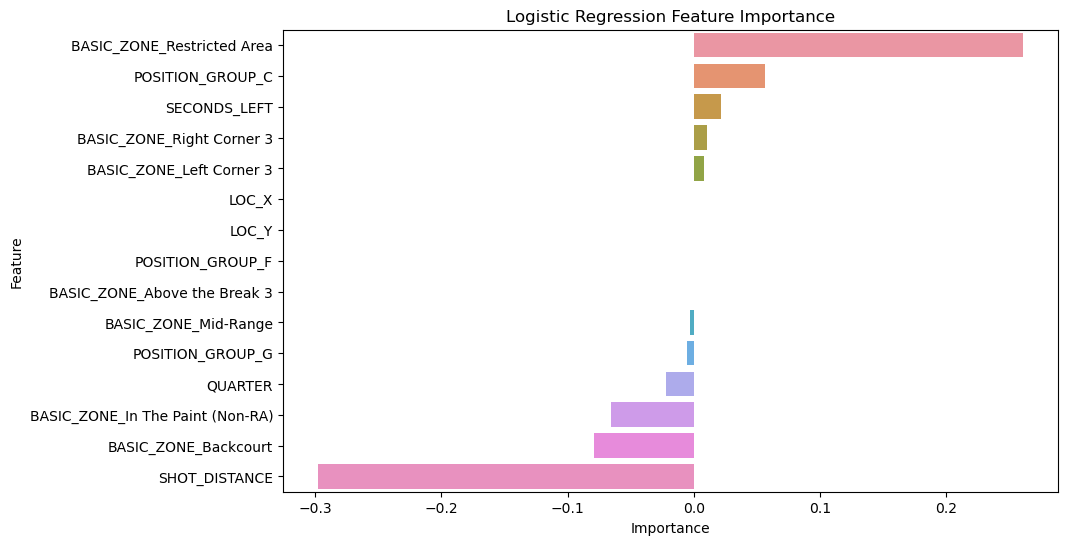

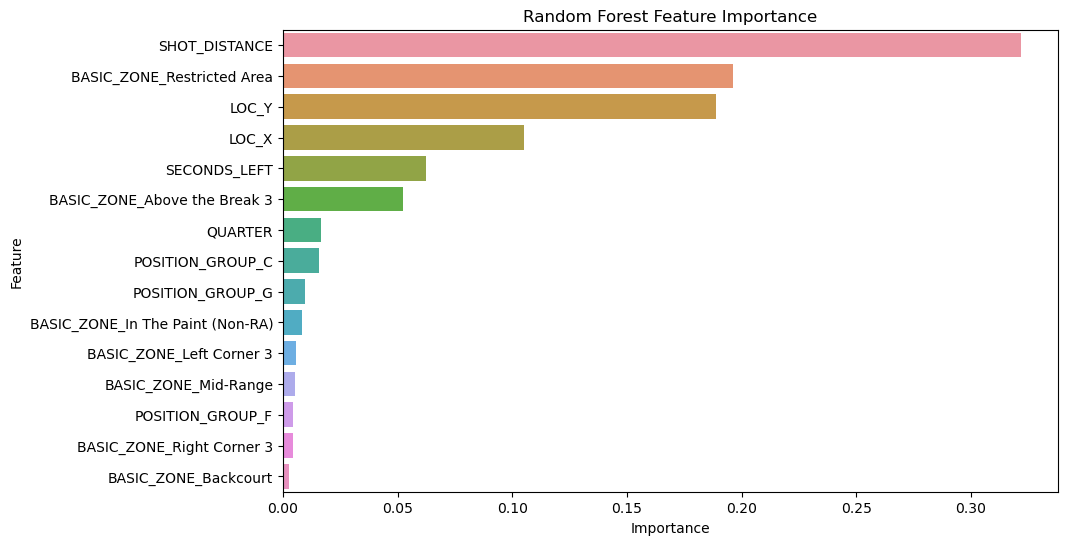

In [35]:
# Logistic Regression feature importance
log_reg = best_lr
log_reg_coef = log_reg.coef_[0]
feature_names = X_train.columns

log_reg_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': log_reg_coef
}).sort_values(by='Importance', ascending=False)

print(log_reg_importance)

# Random Forest feature importance
rf = best_rf
rf_importance = rf.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

print(rf_importance_df)

# Plot feature importance for Logistic Regression
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=log_reg_importance)
plt.title('Logistic Regression Feature Importance')
plt.show()

# Plot feature importance for Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df)
plt.title('Random Forest Feature Importance')
plt.show()

# Conclusions

### Objectives and Approach
The primary objective of this capstone project was to develop predictive models to classify field goals in the 2023 NBA season by position, area, and distance. The project aimed to provide NBA players with insights into the best shot opportunities by leveraging advanced analytics. To achieve this, we utilized Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest classifiers, optimizing their hyperparameters using GridSearchCV.

#### Model Performance
After training and evaluating the models, Random Forest overall produced the best results overall. However, we deemed the current model insufficient in predicting shots made and missed.
### Feature Importance
Feature importance analysis revealed key insights:

#### Logistic Regression: 
The most important features included Restricted Area, Position Group (Center), and Seconds Left indicating that these variables significantly influenced the probability of successful field goals.
#### Random Forest:
The top features identified were Shot Distance, Restricted Area, and Location emphasizing the importance of these variables in predicting field goals. The model's ability to rank features based on their contribution to predictive accuracy provides valuable insights for player strategy and training.
### Practical Implications
The findings from this study demonstrate that shot distance and restricted are ahave the most effect on determining the likelihood of making a field goal in the NBA, but more variables to the model are needed to accurately predict the outcome of a field goal.

#### Limitations and Future Work
While the results are promising, there are limitations to this study:

#### Data Scope: 
The analysis was limited to the 2023 NBA season. Including more seasons could improve the robustness of the models.
Feature Engineering: Additional feature engineering and exploration of other advanced modeling techniques could further enhance performance.
#### Real-time Application: 
Integrating these models into real-time analytics systems for in-game decision support remains a future challenge.
Future work could focus on expanding the dataset, exploring deep learning techniques, and developing real-time applications to provide instant insights during games.

### Final Conclusion
In conclusion, this capstone project did not produce the model desired to predict shot performance. The Random Forest model demonstrated the highest performance, and feature importance analysis provided actionable insights, but the model wasn't strong enough. More variables beyond what was given may need to be analyzed for better predictive value.